In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [ ]:
df = pd.read_csv('Titanic-Dataset.csv')

In [ ]:
print("ขนาดข้อมูล:", df.shape)

ขนาดข้อมูล: (891, 12)


In [ ]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [ ]:
missing_before = df.isnull().sum()

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


**Data Imputation**

In [ ]:
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df['Title'] = df['Title'].replace(['Mlle', 'Ms'], 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

# 1. เติมค่าเฉลี่ยใน Age
df['Age'] = df['Age'].fillna(df['Age'].median())

# 2. เติมค่าที่พบบ่อยที่สุดใน Embarked
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 3. เติม 'Unknown' ให้กับ Cabin เนื่องจากหายไปเยอะเกินกว่าจะเดาได้
df['Cabin'] = df['Cabin'].fillna('Unknown')

print("--- จำนวนข้อมูลที่หายไป (หลังจัดการ) ---")

--- จำนวนข้อมูลที่หายไป (หลังจัดการ) ---


<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_1329/2083426626.py:1: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


**EDA**

การแบ่งชุดข้อมูลแบบ 80:10:10

*   **Training Set (80%)**: ใช้สำหรับให้โมเดลเรียนรู้และปรับน้ำหนัก (weights).
*   **Validation Set (10%)**: ใช้สำหรับปรับแต่ง Hyperparameters ของโมเดลและประเมินประสิทธิภาพระหว่างการฝึก เพื่อป้องกัน Overfitting.
*   **Test Set (10%)**: ใช้สำหรับประเมินประสิทธิภาพสุดท้ายของโมเดลที่ไม่เคยเห็นข้อมูลมาก่อน.

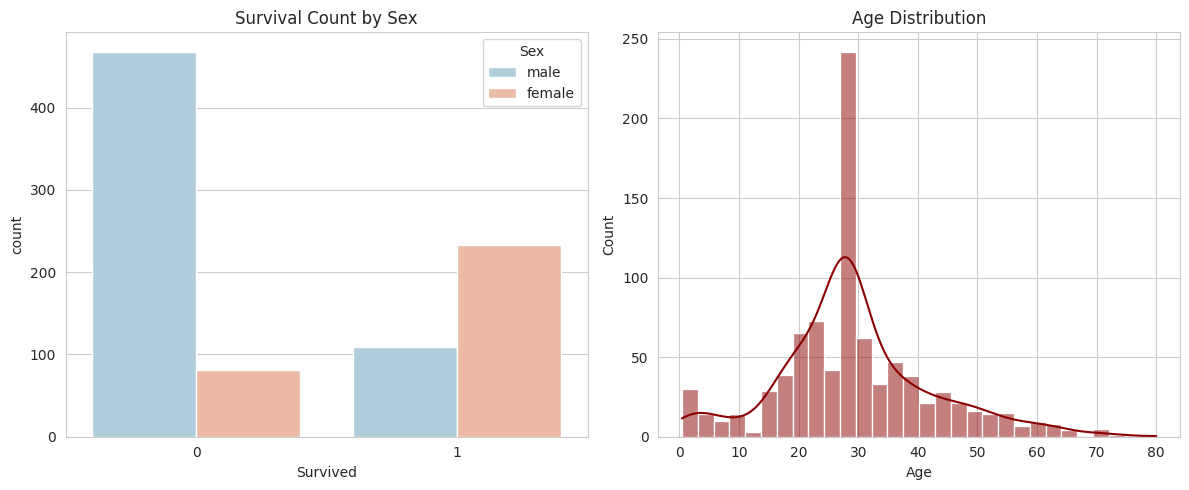

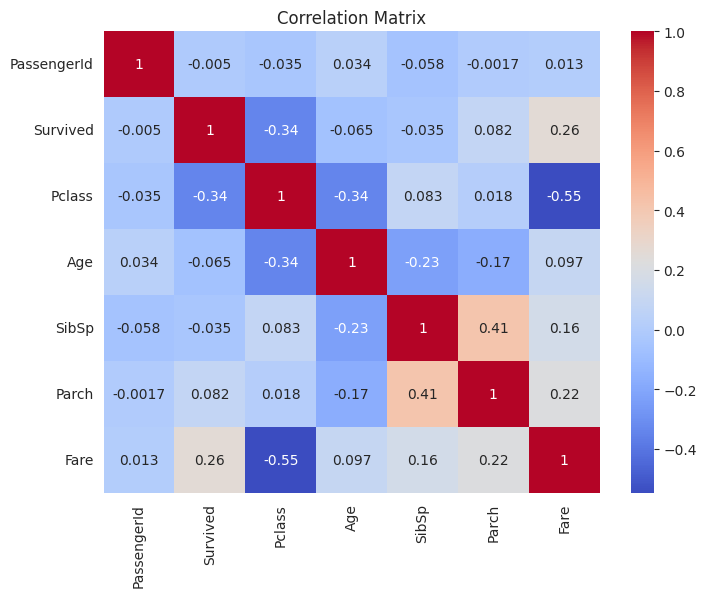

In [ ]:
# ตั้งค่าธีมกราฟ
sns.set_style('whitegrid')

# 1. กราฟแสดงอัตราการรอดชีวิตแยกตามเพศ
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(x='Survived', hue='Sex', data=df, palette='RdBu_r')
plt.title('Survival Count by Sex')

# 2. กราฟแสดงการกระจายตัวของอายุ
plt.subplot(1, 2, 2)
sns.histplot(df['Age'], bins=30, kde=True, color='darkred')
plt.title('Age Distribution')

plt.tight_layout()
plt.show()

# 3. Heatmap ความสัมพันธ์ (Correlation)
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
# สร้างฟีเจอร์ขนาดครอบครัว
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# ลบคอลัมน์ที่ไม่ส่งผลต่อการทำนาย (เก็บ Title ไว้)
df_model = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

# แปลง Sex, Embarked และ Title เป็นตัวเลข
le = LabelEncoder()
for col in ['Sex', 'Embarked', 'Title']:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# แยก X, y
X = df_model.drop('Survived', axis=1)
y = df_model['Survived']

# 1. แบ่งข้อมูลเป็น Training (80%) และ Temp (20%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. แบ่งข้อมูล Temp (20%) เป็น Validation (10%) และ Test (10%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42) # 0.5 ของ 20% คือ 10%

# ทำ Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(f"ขนาดของ Training set: {X_train.shape[0]} samples")
print(f"ขนาดของ Validation set: {X_val.shape[0]} samples")
print(f"ขนาดของ Test set: {X_test.shape[0]} samples")

ขนาดของ Training set: 712 samples
ขนาดของ Validation set: 89 samples
ขนาดของ Test set: 90 samples


**สร้างและเทรนโมเดล Neural Network**

In [ ]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3), # ช่วยลด Overfitting
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# เพิ่ม Callback เพื่อหยุดเมื่อโมเดลหยุดพัฒนา
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

print("กำลังเริ่มเทรนโมเดล...")
history = model.fit(X_train, y_train, epochs=100, batch_size=32,
                    validation_split=0.2, callbacks=[early_stop], verbose=1)

กำลังเริ่มเทรนโมเดล...
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.4956 - loss: 0.6959 - val_accuracy: 0.7622 - val_loss: 0.6462
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6907 - loss: 0.6326 - val_accuracy: 0.7692 - val_loss: 0.5857
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7557 - loss: 0.5827 - val_accuracy: 0.8182 - val_loss: 0.5229
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7733 - loss: 0.5351 - val_accuracy: 0.8462 - val_loss: 0.4673
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8067 - loss: 0.5003 - val_accuracy: 0.8252 - val_loss: 0.4280
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8225 - loss: 0.4737 - val_accuracy: 0.8252 - val_loss: 0.4047
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8243 - loss: 0.4623 - val_accuracy: 0.8322 - val_loss: 0.3964
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8313 - loss: 0.4473 - val_accuracy: 0.8462 - val_loss: 0.

In [ ]:
# ทำนายผล
y_pred = (model.predict(X_test) > 0.5).astype("int32")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


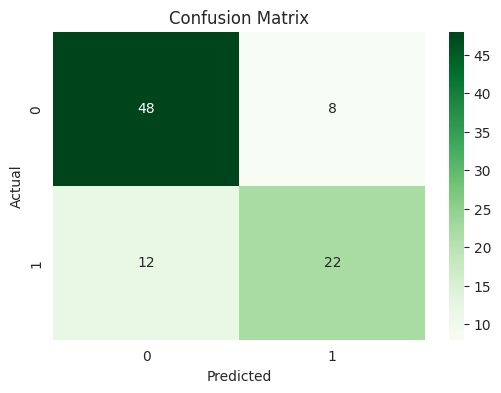

In [ ]:
# 1. แสดง Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [ ]:
#แสดงรายงานสรุป (Precision, Recall, F1-score)
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.80      0.86      0.83        56
           1       0.73      0.65      0.69        34

    accuracy                           0.78        90
   macro avg       0.77      0.75      0.76        90
weighted avg       0.77      0.78      0.77        90



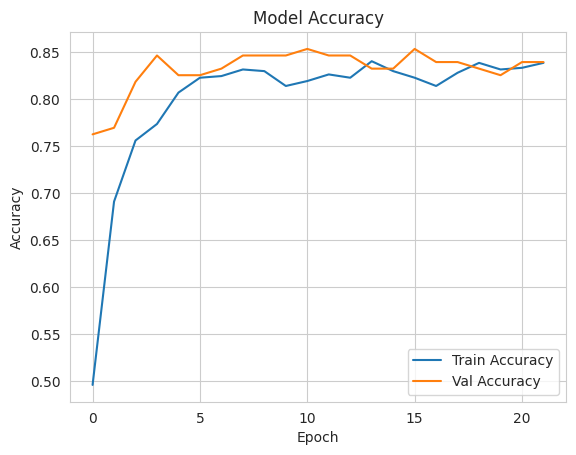

In [ ]:
# 3. กราฟสรุปการเรียนรู้ (Accuracy Curve)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

## แหล่งอ้างอิง (References)

*   Kaggle Titanic - Machine Learning from Disaster: [https://www.kaggle.com/c/titanic](https://www.kaggle.com/c/titanic)
*   TensorFlow Documentation: [https://www.tensorflow.org/api_docs](https://www.tensorflow.org/api_docs)
*   scikit-learn Documentation: [https://scikit-learn.org/stable/documentation.html](https://scikit-learn.org/stable/documentation.html)
*   Pandas Documentation: [https://pandas.pydata.org/docs/](https://pandas.pydata.org/docs/)

In [ ]:
model.save('titanic_model.h5')
print("Model saved to titanic_survival_model.h5")

Model saved to titanic_survival_model.h5
